# FD001 — Exploratory Data Analysis

NASA C-MAPSS turbofan degradation, dataset **FD001**: 100 train engines run to
failure, 100 truncated test engines, one operating condition (sea level), one
fault mode (HPC degradation).

Goal of this notebook: understand the signal available for predicting Remaining
Useful Life (RUL), and decide which sensors and which RUL target to model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cmapss
from cmapss import viz

viz.use_style()
pd.set_option("display.width", 160)

train, test, truth = cmapss.load_dataset("FD001")
train.shape, test.shape, truth.shape

((20631, 27), (13096, 26), (100, 2))

## 1. Shape and integrity

`RUL` in the training frame is derived as `max(cycle) - cycle` within each unit,
which is exact here because every training trajectory runs to failure.

In [2]:
print(f"train: {len(train):,} rows, {train.unit.nunique()} units")
print(f"test:  {len(test):,} rows, {test.unit.nunique()} units")
print(f"missing values: {train.isna().sum().sum()}")
print()
print("cycles per unit:")
print(train.groupby("unit").cycle.max().describe().round(1).to_string())

train: 20,631 rows, 100 units
test:  13,096 rows, 100 units
missing values: 0

cycles per unit:
count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0


Every unit is a complete trajectory with no gaps, and no missing values anywhere.
Lifetimes vary widely — 128 to 362 cycles — which is the "unknown initial wear"
the dataset documentation describes. That spread is the core difficulty: cycle
count alone is a weak predictor, so the model has to read degradation off the
sensors.

findfont: Failed to find font weight semibold, now using 700.


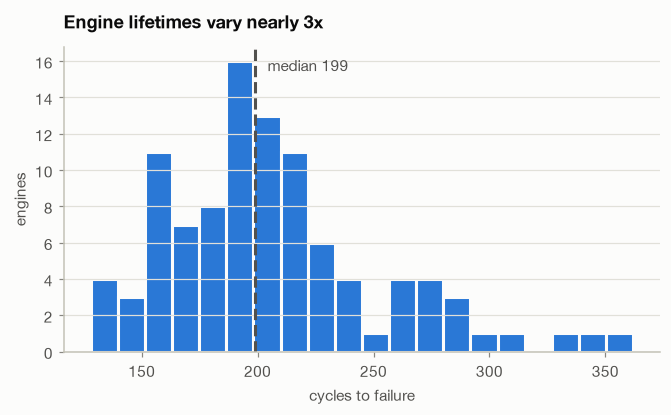

In [3]:
lives = train.groupby("unit").cycle.max()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(lives, bins=20, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=2)
ax.axvline(lives.median(), color=viz.INK_SECONDARY, linewidth=2, linestyle="--")
ax.annotate(
    f"median {lives.median():.0f}",
    xy=(lives.median(), ax.get_ylim()[1] * 0.92),
    xytext=(8, 0), textcoords="offset points",
    color=viz.INK_SECONDARY, fontsize=10,
)
ax.set_title("Engine lifetimes vary nearly 3x")
ax.set_xlabel("cycles to failure")
ax.set_ylabel("engines")
plt.show()

## 2. Which channels carry signal?

Several sensors are recorded but never vary. They are dead weight for any model
and should be dropped before feature engineering.

In [4]:
features = cmapss.OP_SETTING_COLS + cmapss.SENSOR_COLS
variability = train[features].nunique().sort_values()

dead = variability[variability <= 2].index.tolist()
live = [c for c in features if c not in dead]

print("constant / near-constant (drop):")
print(variability[variability <= 2].to_string())
print(f"\n{len(live)} channels retained")

constant / near-constant (drop):
sensor_18       1
op_setting_3    1
sensor_1        1
sensor_16       1
sensor_19       1
sensor_10       1
sensor_5        1
sensor_6        2

16 channels retained


Seven channels are strictly constant, and `sensor_6` takes only two values
(21.60 / 21.61) — a coarsely quantized channel with almost no information. The
two varying operational settings drift within a hair of zero, as expected for a
single-condition dataset; they are kept for now but carry no correlation with
RUL, so FD001 needs no operating-condition normalization.

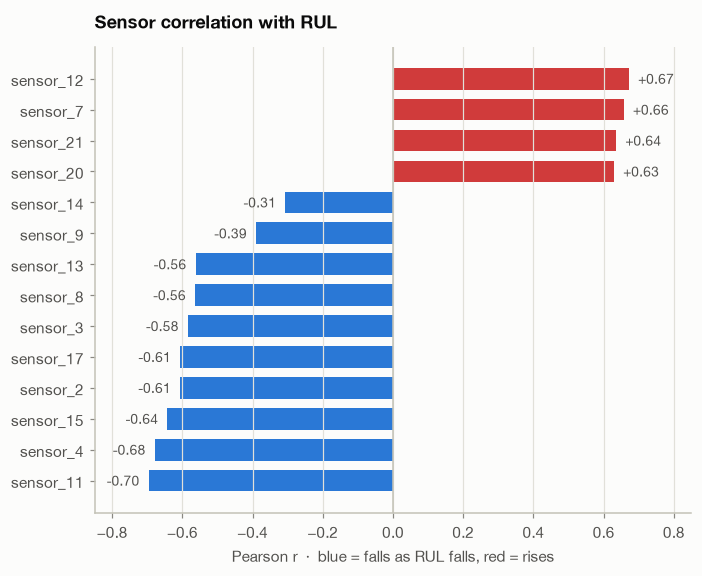

In [5]:
corr = train[live].corrwith(train.RUL).sort_values()
corr_plot = corr.drop(cmapss.OP_SETTING_COLS, errors="ignore")

colors = [viz.DIVERGING_LOW if v < 0 else viz.DIVERGING_HIGH for v in corr_plot]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(corr_plot.index, corr_plot.values, color=colors, height=0.7)
ax.axvline(0, color=viz.BASELINE, linewidth=1)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_title("Sensor correlation with RUL")
ax.set_xlabel("Pearson r  ·  blue = falls as RUL falls, red = rises")
ax.set_xlim(-0.85, 0.85)
for name, v in corr_plot.items():
    ax.annotate(
        f"{v:+.2f}",
        xy=(v, name),
        xytext=(6 if v > 0 else -6, 0), textcoords="offset points",
        va="center", ha="left" if v > 0 else "right",
        color=viz.INK_SECONDARY, fontsize=9,
    )
plt.show()

Sign here is arbitrary — it only says whether a sensor rises or falls as the
engine wears. Magnitude is what matters, and a dozen sensors sit at |r| > 0.55
pooled across all units. Pooled correlation understates the real signal, though,
because each engine starts at a different baseline. The per-unit view is
stronger.

In [6]:
rows = []
for c in live:
    rho = train.groupby("unit")[[c, "cycle"]].apply(
        lambda g, c=c: g[c].corr(g.cycle, method="spearman")
    )
    rows.append({"channel": c, "mean_rho": rho.mean(), "std_rho": rho.std(),
                 "weakest_unit": rho.abs().min()})

monotonic = (
    pd.DataFrame(rows)
    .assign(strength=lambda d: d.mean_rho.abs())
    .sort_values("strength", ascending=False)
    .drop(columns="strength")
    .set_index("channel")
)
monotonic.round(3)

,mean_rho,std_rho,weakest_unit
channel,,,
sensor_11,0.810,0.049,0.646
sensor_12,-0.784,0.062,0.610
sensor_4,0.774,0.045,0.608
sensor_7,-0.752,0.068,0.544
sensor_15,0.711,0.055,0.582
sensor_20,-0.703,0.057,0.580
sensor_21,-0.702,0.059,0.534
sensor_13,0.680,0.199,0.097
sensor_8,0.675,0.199,0.116


`mean_rho` is the average within-engine rank correlation between the sensor and
elapsed cycles — how reliably that channel moves in one direction as an engine
degrades.

Two groups emerge:

- **Consistently monotonic** (|ρ| ≈ 0.63–0.81, low spread, every unit agrees):
  sensors 11, 12, 4, 7, 15, 20, 21, 17, 2, 3. These are the workhorses.
- **Unreliable** (sensors 9, 14; also 8 and 13 to a lesser degree): high mean but
  huge standard deviation, and some units show ρ ≈ 0.02. They trend for most
  engines and not at all for others — dangerous as raw features.

Sensors 9 and 14 are also 0.96-correlated with each other, so they are largely
one channel counted twice.

In [7]:
strong = monotonic.index[:12].tolist()
cm = train[strong].corr().abs()
pairs = (
    cm.where(np.triu(np.ones(cm.shape), 1).astype(bool))
    .stack().sort_values(ascending=False)
)
print("redundant pairs (|r| > 0.85):")
print(pairs[pairs > 0.85].round(3).to_string())

redundant pairs (|r| > 0.85):
Series([], )


## 3. What degradation looks like

Plotting one strong sensor across many engines, aligned by *remaining* life
rather than elapsed cycles, shows the shape the model has to learn.

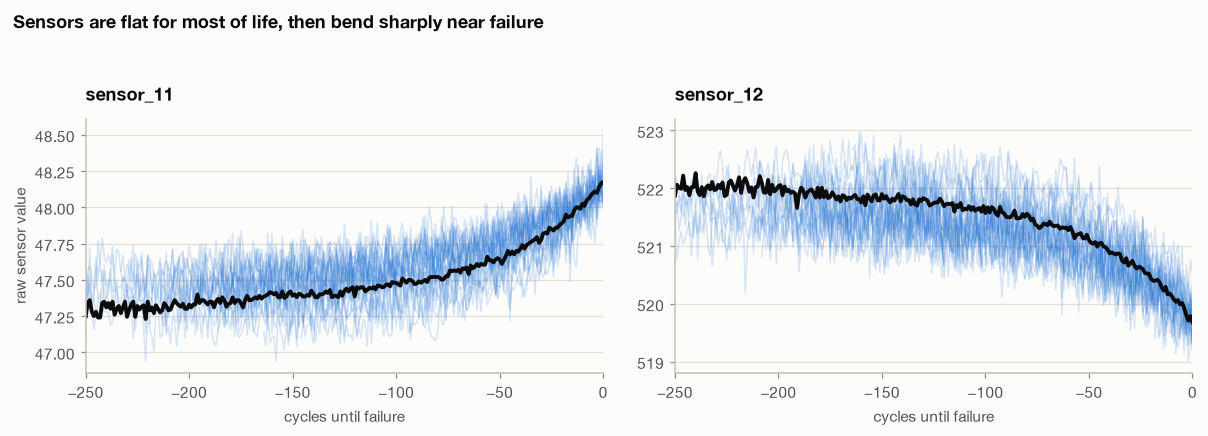

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, sensor in zip(axes, ["sensor_11", "sensor_12"]):
    for unit, g in train.groupby("unit"):
        if unit % 4:
            continue
        ax.plot(-g.RUL, g[sensor], color=viz.SERIES[0], alpha=0.18, linewidth=1)
    med = train.groupby("RUL")[sensor].median()
    ax.plot(-med.index, med.values, color=viz.INK, linewidth=2.5)
    ax.set_title(sensor)
    ax.set_xlabel("cycles until failure")
    ax.set_xlim(-250, 0)

axes[0].set_ylabel("raw sensor value")
fig.suptitle(
    "Sensors are flat for most of life, then bend sharply near failure",
    x=0.008, ha="left", fontsize=12, fontweight="semibold", color=viz.INK,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

Thin blue lines are individual engines (every 4th, for legibility); the black
line is the median across all 100. Two things stand out:

1. **Engines are noisy but share a common trajectory shape.**
2. **The curve is flat far from failure and steep near it.** Degradation is
   effectively unobservable in early life.

Point 2 is the single most important modelling consequence in this dataset, so
it is worth quantifying.

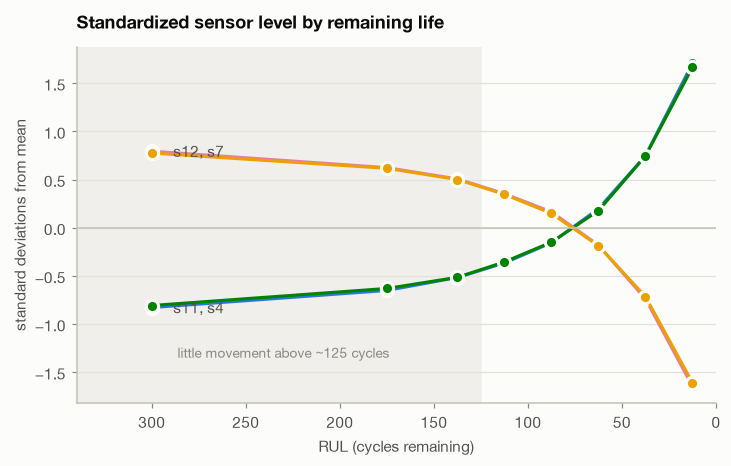

In [9]:
z = train.copy()
tracked = ["sensor_11", "sensor_4", "sensor_12", "sensor_7"]
for c in tracked:
    z[c] = (z[c] - z[c].mean()) / z[c].std()

bins = [0, 25, 50, 75, 100, 125, 150, 200, 400]
profile = z.groupby(pd.cut(z.RUL, bins, right=False), observed=True)[tracked].mean()
centers = [(a + b) / 2 for a, b in zip(bins[:-1], bins[1:])]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for color, c in zip(viz.SERIES, tracked):
    ax.plot(centers, profile[c].values, color=color, marker="o",
            markeredgecolor=viz.SURFACE, markeredgewidth=2)

# The pairs (11, 4) and (12, 7) overlap almost exactly — label each pair once.
for label, y in [("s11, s4", profile.sensor_11.iloc[-1]),
                 ("s12, s7", profile.sensor_12.iloc[-1])]:
    ax.annotate(label, xy=(centers[-1], y),
                xytext=(14, 0), textcoords="offset points",
                color=viz.INK_SECONDARY, fontsize=10, va="center")

ax.axvspan(125, 400, color=viz.NEUTRAL, zorder=0)
ax.annotate("little movement above ~125 cycles", xy=(230, -1.35),
            color=viz.INK_MUTED, fontsize=9, ha="center")
ax.axhline(0, color=viz.BASELINE, linewidth=1)
ax.set_title("Standardized sensor level by remaining life")
ax.set_xlabel("RUL (cycles remaining)")
ax.set_ylabel("standard deviations from mean")
ax.set_xlim(340, 0)
plt.show()

All four strong sensors sit within ~0.8 SD of the mean until roughly 125 cycles
before failure, then move 1.7 SD in the final 25. An engine with 300 cycles left
and one with 150 look nearly identical.

**Implication for the target.** Training against raw RUL asks the model to
distinguish states that are not distinguishable from the sensors, and it will
pay for that with large errors on healthy engines. The standard fix in the
C-MAPSS literature is a *piecewise-linear* target: cap RUL at a constant (~125
here) and let it decay linearly only below that. The elbow above is empirical
support for that cap on FD001.

In [10]:
RUL_CAP = 125
capped = train.RUL.clip(upper=RUL_CAP)
print(f"rows at the cap: {(capped == RUL_CAP).mean():.1%}")

rows at the cap: 39.4%


## 4. The test set

Test trajectories are truncated at a random point before failure, with true RUL
given only for the final cycle of each unit.

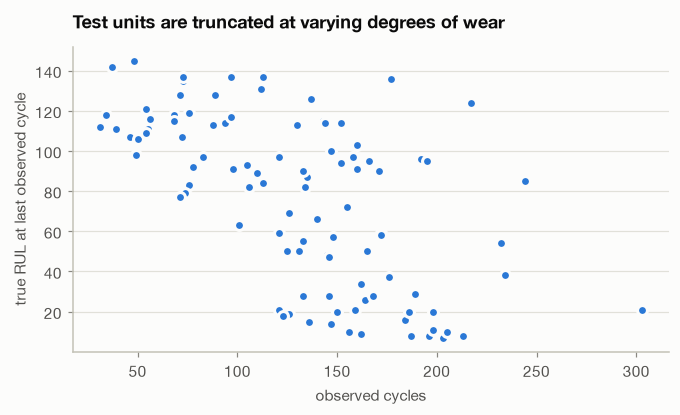

r(observed cycles, true RUL) = -0.60
count    100.0
mean      75.5
std       41.8
min        7.0
25%       32.8
50%       86.0
75%      112.2
max      145.0


In [11]:
test_len = test.groupby("unit").cycle.max()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(test_len, truth.set_index("unit").RUL, s=42,
           color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=2, zorder=3)
ax.set_title("Test units are truncated at varying degrees of wear")
ax.set_xlabel("observed cycles")
ax.set_ylabel("true RUL at last observed cycle")
plt.show()

print(f"r(observed cycles, true RUL) = {test_len.corr(truth.set_index('unit').RUL):.2f}")
print(truth.RUL.describe().round(1).to_string())

Observed length and remaining life are clearly related (r ≈ −0.60): units
truncated later in life tend to be closer to failure. That is mechanical — total
lifetimes share one distribution, so more observed cycles leaves fewer remaining
— but it matters for evaluation: a model that only learned "long history ⇒ low
RUL" would already explain a third of the variance without reading a single
sensor. Beating that shortcut is the bar a sensor-based model must clear.

Also note the tail: some units have only 31 observed cycles, so any windowed
feature must handle short sequences — a 50-cycle window would silently drop
those engines.

`cmapss.load_test_with_rul()` propagates the truth value backward across each
trajectory if per-row test labels are wanted; the conventional benchmark scores
only the final cycle of each unit.

In [12]:
short = test_len[test_len < 50]
print(f"test units with < 50 observed cycles: {len(short)}  (min {test_len.min()})")

test units with < 50 observed cycles: 7  (min 31)


## Findings

1. **Data is clean** — 20,631 rows, no missing values, no gaps.
2. **Drop 8 channels**: `op_setting_3`, sensors 1, 5, 6, 10, 16, 18, 19 are
   constant or binary. Sensors 9 and 14 are 0.96-redundant and inconsistent
   across units — keep at most one, and prefer smoothed versions.
3. **Keep 10 monotonic sensors** — 2, 3, 4, 7, 11, 12, 15, 17, 20, 21 — each
   moving consistently in one direction within essentially every engine.
4. **Cap the RUL target at ~125.** Sensors are flat above that; a linear target
   would demand distinctions the data cannot support.
5. **Normalize per sensor, not per operating condition.** FD001 has one
   condition; op settings carry no RUL signal.
6. **Mind short test sequences** — the shortest test unit has 31 cycles, which
   bounds any rolling-window feature.

Next: build the feature layer (rolling means/slopes over the 10 retained
sensors), then a baseline regressor scored on last-cycle RUL against `truth`.